# SETUP

In [1]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio import features
from rasterio import warp
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt
%matplotlib inline

### Paths

In [2]:
PROJECT_DIR = Path(Path.cwd()).parent
DATA_DIR = Path(PROJECT_DIR, "data")
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
rawfile = RAW_DIR / "output_hh.tif"

In [99]:
with rasterio.open(rawfile) as src:
    mask = src.dataset_mask()
    # Extract feature shapes and values from the array.
    for geom, val in rasterio.features.shapes(
            mask, transform=src.transform):

        # Transform shapes from the src's own coordinate
        # reference system to CRS84 (EPSG:4326).
        geom = rasterio.warp.transform_geom(
            src.crs, 'EPSG:4326', geom, precision=6)

        # Print GeoJSON shapes to stdout.
        print(geom)

{'type': 'Polygon', 'coordinates': [[[7.240334, 43.744561], [7.240334, 43.680412], [7.326851, 43.680412], [7.326851, 43.744561], [7.240334, 43.744561]]]}


In [4]:
def load_dem(path: Path):
    return rasterio.open(path)

In [5]:
dem = load_dem(rawfile)

In [6]:
dem.read(1)

array([[ 0.        ,  0.        ,  0.        , ..., -4.408441  ,
        -4.408441  , -1.1087126 ],
       [ 0.        ,  0.        ,  0.        , ..., -3.2553222 ,
        -3.2553222 , -3.9984558 ],
       [ 0.        ,  0.        ,  0.        , ..., -2.0828218 ,
        -2.0828218 , -2.9753304 ],
       ...,
       [-1.        , -1.        , -1.        , ..., -0.22750424,
        -0.22750424, -0.40057018],
       [-1.        , -1.        , -1.        , ..., -0.54358596,
        -0.54358596, -0.07667027],
       [-1.        , -1.        , -1.        , ..., -0.33956298,
        -0.33956298, -0.36028314]], shape=(1137, 1849), dtype=float32)

In [9]:
compute_flood_mask(dem, 20)

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(1137, 1849))

In [11]:
dem.dataset_mask()

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1137, 1849), dtype=uint8)

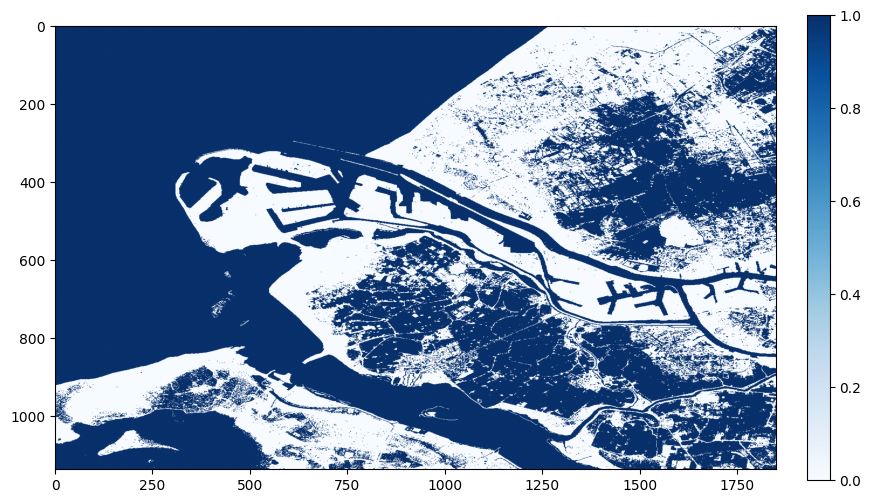

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))
ax1 = ax.imshow(compute_flood_mask(dem, 0), cmap='Blues', vmin=0, vmax=1)
fig.colorbar(ax1, ax=ax, fraction=0.03, pad=0.04)

In [8]:


def compute_flood_mask(dem_ds, water_level: float):
    dem = dem_ds.read(1)  # first band
    nodata = dem_ds.nodata
    mask = dem != nodata
    flooded = (dem <= water_level) & mask
    return flooded

def save_flood_raster(dem_ds, flooded_mask, out_path: Path):
    meta = dem_ds.meta.copy()
    meta.update(dtype=rasterio.uint8, count=1)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(flooded_mask.astype(rasterio.uint8), 1)

def flooded_polygons_from_mask(dem_ds, flooded_mask):
    transform = dem_ds.transform
    shapes = features.shapes(
        flooded_mask.astype(np.uint8),
        mask=flooded_mask,
        transform=transform
    )
    geoms = []
    for geom, value in shapes:
        if value == 1:
            geoms.append(shape(geom))
    gdf = gpd.GeoDataFrame(geometry=geoms, crs=dem_ds.crs)
    return gdf

def summarize_flood_area(flood_gdf):
    flood_gdf = flood_gdf.to_crs(epsg=3857)  # metric CRS
    area_m2 = flood_gdf.area.sum()
    area_km2 = area_m2 / 1e6
    return area_km2

def main():
    dem_path = RAW_DIR / "dem.tif"
    dem_ds = load_dem(dem_path)
    water_level = 2.0  # meters above reference

    flooded_mask = compute_flood_mask(dem_ds, water_level)
    flood_raster_path = PROC_DIR / "flood_mask.tif"
    save_flood_raster(dem_ds, flooded_mask, flood_raster_path)

    flood_gdf = flooded_polygons_from_mask(dem_ds, flooded_mask)
    flood_vec_path = PROC_DIR / "flood_polygons.gpkg"
    flood_gdf.to_file(flood_vec_path, driver="GPKG")

    area_km2 = summarize_flood_area(flood_gdf)
    print(f"Total flooded area: {area_km2:.2f} km²")

# if __name__ == "__main__":
#     main()


In [6]:

raw_dir = Path("../data/raw")
dem_paths = sorted(raw_dir.glob("*.tif")) + sorted(raw_dir.glob("*.tiff"))

# Open all DEMs and keep data + metadata in memory
dem_data = []
for p in dem_paths:
    with rasterio.open(p) as src:
        dem_data.append(
            {
                "path": str(p),
                "array": src.read(1),
                "transform": src.transform,
                "crs": src.crs,
                "nodata": src.nodata,
            }
        )

print(f"Loaded {len(dem_data)} DEM file(s) from {raw_dir}")

Loaded 1 DEM file(s) from ../data/raw


In [11]:
water_level = 2  # Example water level for flood risk mapping
flood_risk_maps = []
for dem in dem_data:
    flood_risk = dem["array"] < water_level
    flood_risk_maps.append(
        {
            "path": dem["path"],
            "flood_risk": flood_risk,
            "transform": dem["transform"],
            "crs": dem["crs"],
        }
    )

In [12]:
flood_risk_maps[0]["flood_risk"]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False]],
      shape=(2500, 2437))